In [66]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
import tensorflow as tf
from tensorflow.keras import layers, models

In [67]:
# Load dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)

print("Testing Images:", X_test.shape)
print("Testing Labels:", y_test.shape)

Training Images: (60000, 28, 28)
Training Labels: (60000,)
Testing Images: (10000, 28, 28)
Testing Labels: (10000,)


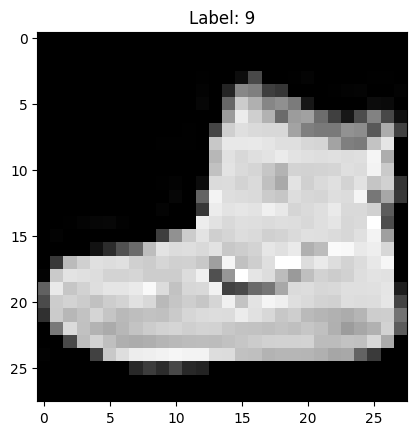

In [68]:
#Visualize Dataset
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [69]:
#Normalize Data
X_train = X_train / 255.0
X_test = X_test / 255.0

In [70]:
#Add Channel Dimension
X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(10000, 28, 28, 1)

print(X_train.shape)

(60000, 28, 28, 1)


In [71]:
#Build Convolution Layer FROM SCRATCH
class ConvolutionLayer:

    def __init__(self, num_filters, filter_size):

        self.num_filters = num_filters
        self.filter_size = filter_size

        # Random filters
        self.filters = np.random.randn(
            num_filters,
            filter_size,
            filter_size
        ) / (filter_size * filter_size)


    def iterate_regions(self, image):

        h, w = image.shape

        for i in range(h - self.filter_size + 1):
            for j in range(w - self.filter_size + 1):

                region = image[
                    i:(i + self.filter_size),
                    j:(j + self.filter_size)
                ]

                yield region, i, j


    def forward(self, input):

        self.last_input = input

        h, w = input.shape

        output = np.zeros((
            h - self.filter_size + 1,
            w - self.filter_size + 1,
            self.num_filters
        ))

        for region, i, j in self.iterate_regions(input):

            output[i, j] = np.sum(
                region * self.filters,
                axis=(1,2)
            )

        return output

In [72]:
#Test Convolution Layer
conv = ConvolutionLayer(8, 3)

output = conv.forward(X_train[0][:,:,0])

print(output.shape)

#Explanation:
#Input = 28×28
#Filter = 3×3
#Output = 26×26

(26, 26, 8)


In [73]:
#Build Max Pooling Layer
class MaxPool:

    def iterate_regions(self, image):

        h, w, num_filters = image.shape

        new_h = h // 2
        new_w = w // 2

        for i in range(new_h):
            for j in range(new_w):

                region = image[
                    (i*2):(i*2 + 2),
                    (j*2):(j*2 + 2)
                ]

                yield region, i, j


    def forward(self, input):

        self.last_input = input

        h, w, num_filters = input.shape

        output = np.zeros((h//2, w//2, num_filters))

        for region, i, j in self.iterate_regions(input):

            output[i, j] = np.amax(region, axis=(0,1))

        return output

In [74]:
#Test MaxPool
pool = MaxPool()

pooled_output = pool.forward(output)

print(pooled_output.shape)

(13, 13, 8)


In [76]:
#Build Fully Connected Layer
class Softmax:

    def __init__(self, input_len, nodes):

        self.weights = np.random.randn(input_len, nodes) / input_len
        self.biases = np.zeros(nodes)


    def forward(self, input):

        self.last_input_shape = input.shape

        input = input.flatten()
        self.last_input = input

        totals = np.dot(input, self.weights) + self.biases

        self.last_totals = totals

        exp = np.exp(totals)

        return exp / np.sum(exp, axis=0)

    #Backpropagation (Backward Pass)
    def backward(self, d_L_d_out, learning_rate):
      for i, gradient in enumerate(d_L_d_out):

        if gradient == 0:
            continue

        t_exp = np.exp(self.last_totals)
        S = np.sum(t_exp)

        d_out_d_t = -t_exp[i] * t_exp / (S**2)
        d_out_d_t[i] = t_exp[i] * (S - t_exp[i]) / (S**2)

        d_t_d_w = self.last_input
        d_t_d_inputs = self.weights

        d_L_d_t = gradient * d_out_d_t

        d_L_d_w = d_t_d_w[np.newaxis].T @ d_L_d_t[np.newaxis]

        d_L_d_b = d_L_d_t

        d_L_d_inputs = d_t_d_inputs @ d_L_d_t

        self.weights -= learning_rate * d_L_d_w
        self.biases -= learning_rate * d_L_d_b

        return d_L_d_inputs.reshape(self.last_input_shape)



In [77]:
#Create CNN Model
conv = ConvolutionLayer(8, 3)
pool = MaxPool()
softmax = Softmax(13 * 13 * 8, 10)

In [78]:
#Forward Pass Function
def forward(image, label):

    # Convolution
    out = conv.forward((image / 255)[:,:,0])

    # Pooling
    out = pool.forward(out)

    # Fully Connected
    out = softmax.forward(out)

    # Loss
    loss = -np.log(out[label])

    # Accuracy
    acc = 1 if np.argmax(out) == label else 0

    return out, loss, acc

In [79]:
#Test Forward Pass
out, loss, acc = forward(X_train[0], y_train[0])

print("Loss:", loss)
print("Accuracy:", acc)

Loss: 2.302587724825893
Accuracy: 0


In [80]:
#Training Function
def train(image, label, lr=0.005):
      out, loss, acc = forward(image, label)

      gradient = np.zeros(10)
      gradient[label] = -1 / out[label]

      softmax.backward(gradient, lr)

      return loss, acc

In [81]:
#Create Lists to Store Results

train_losses = []
train_accuracies = []

test_losses = []
test_accuracies = []

In [82]:
#CNN Training

model = models.Sequential([

    layers.Conv2D(
        8,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(10, activation='softmax')
])

In [84]:
#Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [85]:
#train model
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.8226 - loss: 0.5145 - val_accuracy: 0.8573 - val_loss: 0.4049
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 11ms/step - accuracy: 0.8711 - loss: 0.3660 - val_accuracy: 0.8673 - val_loss: 0.3771
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.8827 - loss: 0.3336 - val_accuracy: 0.8806 - val_loss: 0.3451
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.8890 - loss: 0.3143 - val_accuracy: 0.8820 - val_loss: 0.3298
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.8934 - loss: 0.2996 - val_accuracy: 0.8772 - val_loss: 0.3376


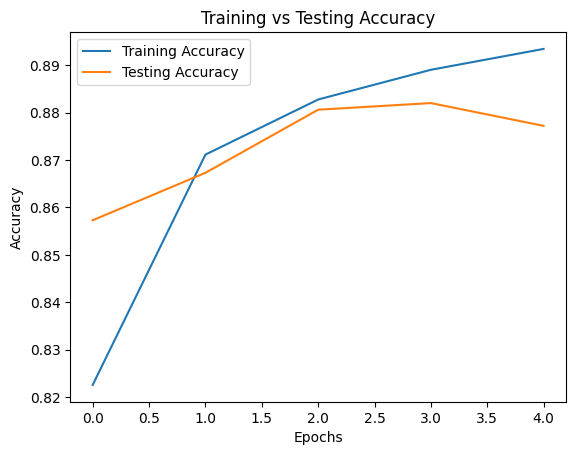

In [86]:
#accuracy graph

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(
    history.history['val_accuracy'],
    label='Testing Accuracy'
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.title("Training vs Testing Accuracy")

plt.legend()

plt.show()

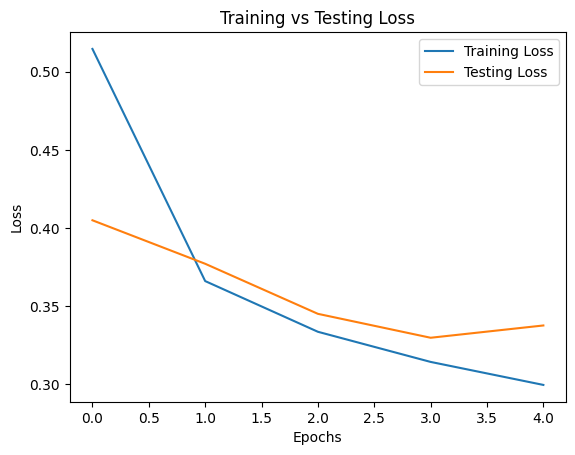

In [87]:
#loss graph

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(
    history.history['val_loss'],
    label='Testing Loss'
)

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.title("Training vs Testing Loss")

plt.legend()

plt.show()

In [88]:
#final evaluation
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Final Test Accuracy:", test_accuracy)
print("Final Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8772 - loss: 0.3376
Final Test Accuracy: 0.8772000074386597
Final Test Loss: 0.33762162923812866
